# Maximum Likelihood Estimation (MLE) 

For the explanation purpose I will an exponential distribution, which is commonly used to model the time until an event occurs, such as the waiting time between events. 

The Likelihood function represents the probability of observing the given data ($x$) under a specific model parameterization ($\lambda$):

$L(\lambda | x) = \lambda e^{- \lambda x}$ ,

**Estimation comes to finding the value of the lambda coefficient to maximize the fit of the function to the data!**

In [11]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt

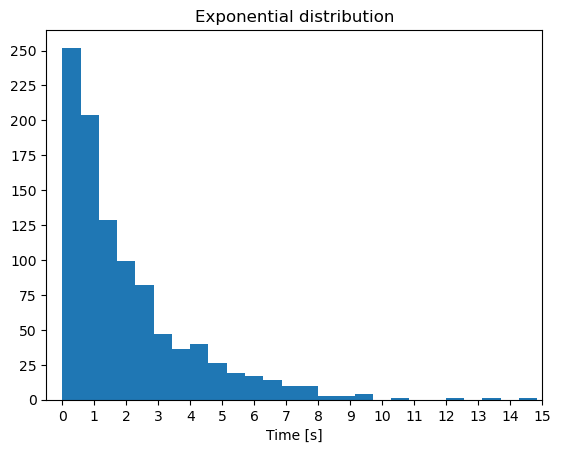

In [12]:
# Import data
np.random.seed(0)
data = np.random.exponential(1/0.5, size=1000) # lambda coefficient should be estimated around 0.5

# Histogram
plt.hist(data, bins=30)
plt.xlim(-0.5, 15)
plt.xticks(np.arange(0, 16, 1))
plt.yticks(np.arange(0, 275, 25))
plt.title("Exponential distribution")
plt.xlabel("Time [s]")
plt.show()

# Likelihood and Log-Likelihood functions

- Likelihood $L(\lambda | x)$ is desribed by the following equation:

$L(\lambda | x) = \prod_{i=1}^{k} \lambda e^{-\lambda x_i}$

- Log-Likelihood $log(L(\lambda | x))$ is desribed by the following equation:

$\log(L(\lambda | x)) = \sum_{i=1}^{k} \log (\lambda e^{-\lambda x_i})$

- It's often more convenient to work with the log-likelihood function, especially for computational purposes. 

#### **Calculations**:

$\log(L(\lambda | x)) = \sum_{i=1}^{k} \log (\lambda e^{-\lambda x_i})$

$=\sum_{i=1}^{k} \log (\lambda) + \sum_{i=1}^{k} \log (e^{-\lambda x_i})$

$=k\log (\lambda) + \sum_{i=1}^{k} \log (e^{-\lambda x_i})$

$=k\log (\lambda) + \sum_{i=1}^{k} -\lambda x_i$

$=k\log (\lambda) -\lambda \sum_{i=1}^{k} x_i$

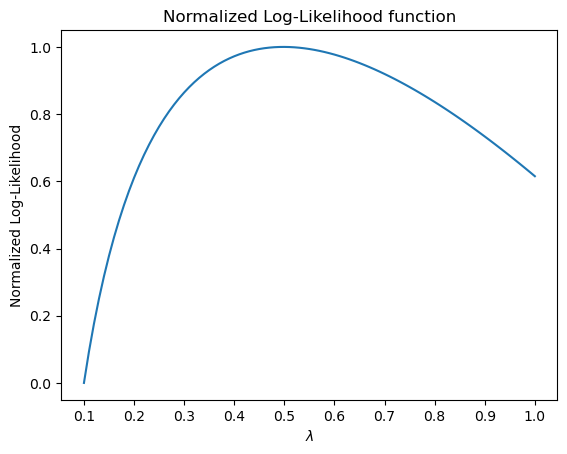

In [14]:
def log_likelihood(lmb: float, data: list[float]) -> float:
    k = len(data)
    return k * np.log(lmb) - lmb * np.sum(data)

lambda_domain = list(np.linspace(0.1, 1, 100).round(2))
likelihood = [log_likelihood(lmb=i, data=data) for i in lambda_domain]
likelihood_normalized = [((i - np.min(likelihood)) / (np.max(likelihood) - np.min(likelihood))) for i in likelihood]

plt.plot(lambda_domain, likelihood_normalized)
plt.xlabel("$\lambda$")
plt.ylabel("Normalized Log-Likelihood")
plt.xticks(np.arange(0.1, 1.1, 0.1))
plt.title("Normalized Log-Likelihood function")
plt.show()

# Maximization

To find the maximal value of the plot we will calculate the first derivative of the likelihood function:

$\frac{d}{d\lambda}\ln(L(\lambda|x)) = \frac{d}{d\lambda}(k\ln(\lambda) - \lambda \sum_{i=1}^{k}x_i)$

$=\frac{d}{d\lambda}(k \ln \lambda) - \frac{d}{d\lambda}(\lambda \sum_{i=1}^{k}x_i)$

$=k \frac{d}{d\lambda}(\ln \lambda) - \sum_{i=1}^{k}x_i\frac{d}{d\lambda}(\lambda)$

$=k \frac{1}{\lambda} - \sum_{i=1}^{k}x_i$

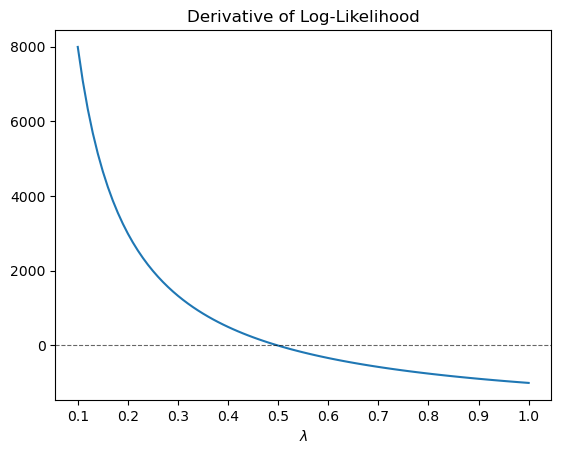

In [15]:
def dydx_log_likelihood(lmb: float, data: list[float]) -> float:
    k = len(data)
    return k/lmb - np.sum(data)

lambda_domain = list(np.linspace(0.1, 1, 100).round(2))
dydx_likelihood = [dydx_log_likelihood(lmb=i, data=data) for i in lambda_domain]

plt.plot(lambda_domain, dydx_likelihood)
plt.xlabel("$\lambda$")
plt.xticks(np.arange(0.1, 1.1, 0.1))
plt.axhline(0, linestyle="--", linewidth=0.8, alpha=0.6, color="black")
plt.title("Derivative of Log-Likelihood")
plt.show()

# Parameter estimate

We can find critical point for the derivative of the log likelihood function with respect to lambda and set it equal to zero to solve for lambda:

$\frac{k}{\lambda} - \sum_{i=1}^{k}x_i = 0$

$\frac{k}{\lambda} = \sum_{i=1}^{k}x_i$

$\frac{\lambda}{k} = \frac{1}{\sum_{i=1}^{k}x_i}$

$\lambda = \frac{k}{\sum_{i=1}^{k}x_i}$

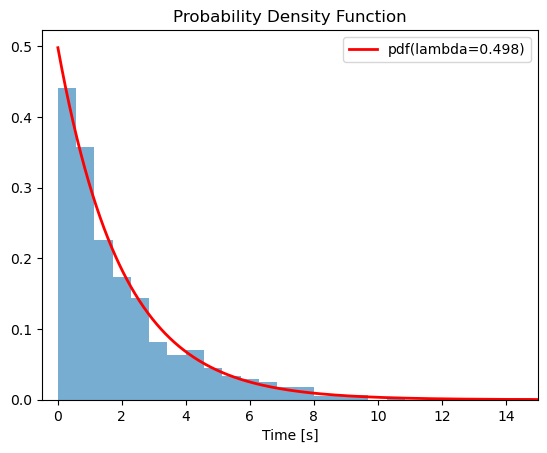

In [16]:
def mle_lambda(data: list[float]) -> float:
    k = len(data)
    return k / np.sum(data)

coeff = mle_lambda(data=data)

def exponential_pdf(lmb: float, x: float) -> float:
    return lmb * np.e ** (- lmb * x)

x = np.linspace(np.min(data), np.max(data), len(data))

# Histogram
plt.hist(data, bins=30, density=True, alpha=0.6)
plt.plot(x, exponential_pdf(lmb=coeff, x=x), label=f"pdf(lambda={coeff:.3f})", color="red", linewidth=2)
plt.xlim(-0.5, 15)
plt.title("Probability Density Function")
plt.xlabel("Time [s]")
plt.legend()
plt.show()

# Expected value

Using Sympy we will calculate the expected value of the distribution, given by the formula:

$E(x) = Value * Probability$

$E(x) = x \int_{0}^{\infty} \lambda e^{- \lambda x} dx$

In our case, it is the value of an event to occur on average.

In [17]:
import sympy as smp

la, x = smp.symbols("lambda, x", real=True, positive=True)
expression = la * smp.E ** (- la * x)
smp.integrate((x * expression), (x, 0, smp.oo))


1/lambda

In [18]:
1 / coeff

2.007080417521418

On avarage we can expect that an event will occur every 2 seconds.

Interestingly, we can conclude:

$\overline{x} = \frac{1}{\lambda} = \frac{\sum_{i=1}^{k}x_i}{k}$

In [19]:
np.mean(data)

2.007080417521418